<a href="https://colab.research.google.com/github/Hyoseok-An/26-1_snubioinformatics/blob/main/Your_own_analysis_(Hyoseok_An)_draft2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIN28A와 rRNA의 interaction을 보고자 함

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


실습용 Bioconda 환경 설치하기
Google CoLab에서 접속하지 않고, 본인 컴퓨터 또는 연구실 워크스테이션 등 다른 컴퓨터를 쓰시는 경우에는 따로 실습용 Bioconda 환경을 구축해서 이 노트북을 그 환경 안에서 띄우시면 됩니다.

CoLab을 쓰시는 분들은 다음에 따라서 실습용 프로그램들을 쉽게 설치할 수 있도록 Bioconda 환경을 만듭니다. 실행하고 진행상황을 관찰하다가 에러로 보이는 것이 있으면 잘 읽어보고 해결합니다.

파이썬 모듈들은 Colab쪽의 파이썬 인터프리터를 바꿀 수 없기 때문에 Conda에 설치하더라도 사용하기 어렵습니다. 파이썬 모듈은 pip 명령어로 설치하시면 Colab에서 불러와서 사용할 수 있습니다.

환경 초기화에 관련된 스크립트는 GitHub 프로젝트에 있습니다.

In [13]:
!git clone https://github.com/hyeshik/colab-biolab.git
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

fatal: destination path 'colab-biolab' already exists and is not an empty directory.
./
./root/
./root/.tmux.conf
./root/.bashrc.biolab
./root/.profile
./root/.vimrc
./root/.bin.priority/
./root/.bin.priority/pip3
./root/.bin.priority/pip
./root/.bin.priority/pip2
./root/.condarc
PREFIX=/root/conda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /root/conda
Activated conda environment `lab'!


In [14]:
!mkdir -p /content/binfo1-mywork
!cp -r /content/drive/MyDrive/binfo1-datapack1/* /content/binfo1-mywork

In [15]:
!pip install pysam
# Conda 환경에 samtools와 gsnap을 직접 설치
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install -c bioconda bowtie2 samtools -y

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: | / - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - bowtie2
    - samtools


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    bowtie2-2.5.5              |       ha27dd3b_0        11.1 MB  bioconda
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    conda-26.3.2             

In [16]:
import os
import subprocess

WORKDIR = "/content/binfo1-mywork"
RRNA_DIR = f"{WORKDIR}/rrna_analysis"
os.makedirs(RRNA_DIR, exist_ok=True)
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

# 1. 레퍼런스 FASTA 다운로드
if not os.path.exists(f"{RRNA_DIR}/mouse_rRNA_ref.fasta"):
    subprocess.run(f"wget -O {RRNA_DIR}/mouse_rRNA_ref.fasta 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nucleotide&id=BK000964.1&rettype=fasta&retmode=text'", shell=True)

# 2. CLIP 및 Control BAM에서 Unmapped Reads 추출 (FASTQ)
subprocess.run(f"samtools fastq -f 4 {WORKDIR}/CLIP-35L33G.bam > {RRNA_DIR}/unmapped_CLIP.fastq", shell=True, env=env)
subprocess.run(f"samtools fastq -f 4 {WORKDIR}/RNA-control.bam > {RRNA_DIR}/unmapped_control.fastq", shell=True, env=env)

print("✅ 레퍼런스 다운로드 및 FASTQ 추출 완료!")

✅ 레퍼런스 다운로드 및 FASTQ 추출 완료!


In [18]:
import subprocess
import os

WORKDIR = "/content/binfo1-mywork"
RRNA_DIR = f"{WORKDIR}/rrna_analysis"
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

bash_script = f"""
WORKDIR="{WORKDIR}"
RRNA_DIR="{RRNA_DIR}"

echo "====== 🎯 [Step 1] Index 빌드 시작 ======"
bowtie2-build ${{RRNA_DIR}}/mouse_rRNA_ref.fasta ${{RRNA_DIR}}/rrna_db

echo "====== 🚀 [Step 2] CLIP 데이터 매핑 및 Depth 추출 ======"
bowtie2 -x ${{RRNA_DIR}}/rrna_db -U ${{RRNA_DIR}}/unmapped_CLIP.fastq -S ${{RRNA_DIR}}/lin28a_rrna.sam --local -p 4
samtools view -S -b ${{RRNA_DIR}}/lin28a_rrna.sam | samtools sort -o ${{RRNA_DIR}}/lin28a_rrna_sorted.bam
samtools index ${{RRNA_DIR}}/lin28a_rrna_sorted.bam
samtools depth -a ${{RRNA_DIR}}/lin28a_rrna_sorted.bam > ${{RRNA_DIR}}/clip_depth.txt

echo "====== 🚀 [Step 3] Control 데이터 매핑 및 Depth 추출 ======"
bowtie2 -x ${{RRNA_DIR}}/rrna_db -U ${{RRNA_DIR}}/unmapped_control.fastq -S ${{RRNA_DIR}}/control_rrna.sam --local -p 4
samtools view -S -b ${{RRNA_DIR}}/control_rrna.sam | samtools sort -o ${{RRNA_DIR}}/control_rrna_sorted.bam
samtools index ${{RRNA_DIR}}/control_rrna_sorted.bam
samtools depth -a ${{RRNA_DIR}}/control_rrna_sorted.bam > ${{RRNA_DIR}}/control_depth.txt

echo "✅ 정렬 및 Depth 추출 완전 완료!"
"""

# 수정된 부분: ['bash', '-c', bash_script] 로 스크립트를 정확히 전달합니다. (stdin 파이프 제거)
process = subprocess.Popen(['bash', '-c', bash_script], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=env)

while True:
    output = process.stdout.readline()
    if output == '' and process.poll() is not None:
        break
    if output:
        print(output.strip())

====== 🎯 [Step 1] Index 빌드 시작 ======
Settings:
Output files: "/content/binfo1-mywork/rrna_analysis/rrna_db.*.bt2"
Line rate: 6 (line is 64 bytes)
Lines per side: 1 (side is 64 bytes)
Offset rate: 4 (one in 16)
FTable chars: 10
Strings: unpacked
Max bucket size: default
Max bucket size, sqrt multiplier: default
Max bucket size, len divisor: 4
Difference-cover sample period: 1024
Endianness: little
Actual local endianness: little
Sanity checking: disabled
Assertions: disabled
Random seed: 0
Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
/content/binfo1-mywork/rrna_analysis/mouse_rRNA_ref.fasta
Building a SMALL index
Reading reference sizes
Time reading reference sizes: 00:00:00
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
Time to join reference sequences: 00:00:00
bmax according to bmaxDivN setting: 11327
Using parameters --bmax 8496 --dcv 1024
Doing ahead-of-time memory usage test
Passed!  Constructing with the

In [19]:
import pysam

# Open your main CLIP BAM file
samfile = pysam.AlignmentFile("/content/binfo1-mywork/CLIP-35L33G.bam", "rb")

# Print all reference sequence names (chromosomes) present in the alignment header
print("Chromosomes/Contigs present in BAM:")
for chrom in samfile.references:
    if "rRNA" in chrom or "rnDNA" in chrom or "BK000964" in chrom:
        print(f"-> Found rRNA contig: {chrom}")

# Count total unmapped reads
unmapped_count = samfile.unmapped
print(f"\nTotal unmapped reads in this BAM: {unmapped_count:,}")

Chromosomes/Contigs present in BAM:

Total unmapped reads in this BAM: 2,291,075


In [20]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.0 MB/s eta 0:00:00


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

RRNA_DIR = "/content/binfo1-mywork/rrna_analysis"

# 1. samtools depth 결과 불러오기 (컬럼: Chromosome, Position, Depth)
clip_df = pd.read_csv(f"{RRNA_DIR}/clip_depth.txt", sep='\t', header=None, names=['Chrom', 'Position', 'CLIP_Depth'])
control_df = pd.read_csv(f"{RRNA_DIR}/control_depth.txt", sep='\t', header=None, names=['Chrom', 'Position', 'Control_Depth'])

# 2. 데이터 병합
norm_df = pd.merge(clip_df, control_df, on=['Chrom', 'Position'])

# 3. RPM 기반 노멀라이징
TOTAL_CLIP_READS = 169088
TOTAL_CONTROL_READS = 12594234

norm_df["CLIP_RPM"] = (norm_df["CLIP_Depth"] / TOTAL_CLIP_READS) * 1_000_000
norm_df["Control_RPM"] = (norm_df["Control_Depth"] / TOTAL_CONTROL_READS) * 1_000_000

# Enrichment Score 산출 (Pseudocount 1 추가)
norm_df["Enrichment_Score"] = (norm_df["CLIP_RPM"] + 1) / (norm_df["Control_RPM"] + 1)
# 노이즈 필터링
norm_df.loc[norm_df["CLIP_Depth"] < 50, "Enrichment_Score"] = 0

# CSV 저장
norm_df.to_csv(f"{RRNA_DIR}/lin28a_rrna_normalized_scores.csv", index=False)

print("✅ 노멀라이징 및 데이터 통합 완료!")

✅ 노멀라이징 및 데이터 통합 완료!


In [22]:
import pandas as pd
from scipy.signal import find_peaks

def get_rrna_region(pos):
    """
    NCBI GenBank: BK000964.3 (Mouse rDNA complete repeating unit)
    공식 주석(Annotation) 기반 좌표 매핑 함수
    """
    # 1. 45S pre-rRNA 전사체 내부 영역
    if 1 <= pos <= 4007:
        return "5' ETS (External Transcribed Spacer)"
    elif 4008 <= pos <= 5877:
        return "18S rRNA (Small Subunit)"
    elif 5878 <= pos <= 6877:
        return "ITS1 (Internal Transcribed Spacer 1)"
    elif 6878 <= pos <= 7034:
        return "5.8S rRNA"
    elif 7035 <= pos <= 8122:
        return "ITS2 (Internal Transcribed Spacer 2)"
    elif 8123 <= pos <= 12852:
        return "28S rRNA (Large Subunit)"
    elif 12853 <= pos <= 13403:
        return "3' ETS (External Transcribed Spacer)"

    # 2. 유전자 간 스페이서 영역
    elif 13404 <= pos <= 45306:
        return "IGS (Intergenic Spacer)"

    # 3. 예외 처리
    else:
        return "Out of Range (레퍼런스 범위 초과)"


print("=== 🎯 개선된 LIN28A-rRNA 결합 피크 검출 (RPM 정규화 반영) ===\n")

# 1. 이전 단계에서 RPM 정규화까지 마친 norm_df의 Enrichment_Score를 1D 배열로 추출
enrichment_array = norm_df["Enrichment_Score"].values

# 2. find_peaks 모듈을 사용하여 메인 피크만 병합하여 검출
# height: 최소 5배 이상 농축된 곳만 추출 (필요에 따라 조절)
# distance: 50bp 이내에 존재하는 자잘한 봉우리들은 가장 높은 것 딱 1개만 남김
peak_indices, properties = find_peaks(enrichment_array, height=5.0, distance=50)

# 3. 결과 출력 및 모티프 탐색 준비
peaks = []
for idx in peak_indices:
    pos = norm_df.loc[idx, "Position"]
    score = enrichment_array[idx]
    clip_depth = norm_df.loc[idx, "CLIP_Depth"]
    peaks.append((pos, score, clip_depth))

# Score가 높은 순으로 정렬
peaks = sorted(peaks, key=lambda x: x[1], reverse=True)

for rank, (pos, score, depth) in enumerate(peaks[:5], 1):
    region_name = get_rrna_region(pos)
    print(f"📍 [Peak {rank}] 좌표: {pos:,} bp | Enrichment Score: {score:.2f}배 | CLIP Depth: {depth:,}")
    print(f"   🧬 리보솜 유전자 위치: {region_name}")
    print("-" * 70)

=== 🎯 개선된 LIN28A-rRNA 결합 피크 검출 (RPM 정규화 반영) ===

📍 [Peak 1] 좌표: 24,589 bp | Enrichment Score: 1084.69배 | CLIP Depth: 591
   🧬 리보솜 유전자 위치: IGS (Intergenic Spacer)
----------------------------------------------------------------------
📍 [Peak 2] 좌표: 2,392 bp | Enrichment Score: 484.78배 | CLIP Depth: 13,984
   🧬 리보솜 유전자 위치: 5' ETS (External Transcribed Spacer)
----------------------------------------------------------------------
📍 [Peak 3] 좌표: 6,478 bp | Enrichment Score: 465.56배 | CLIP Depth: 2,185
   🧬 리보솜 유전자 위치: ITS1 (Internal Transcribed Spacer 1)
----------------------------------------------------------------------
📍 [Peak 4] 좌표: 39,889 bp | Enrichment Score: 308.03배 | CLIP Depth: 85
   🧬 리보솜 유전자 위치: IGS (Intergenic Spacer)
----------------------------------------------------------------------
📍 [Peak 5] 좌표: 6,938 bp | Enrichment Score: 293.93배 | CLIP Depth: 25,424
   🧬 리보솜 유전자 위치: 5.8S rRNA
----------------------------------------------------------------------


RPM normalization을 반영하여 보고자 하는 rRNA의 위치를 정하고 이것이 LIN28A와 관련하여 biological important feature인지 validation 하고자 한다.
1. [peak 5] CLIP Depth : 25,424인 5.8S rRNA 6,938bp

2. [peak 2] CLIP Depth : 13,984인 5' ETS rRNA 2,392bp

**1. [peak 5] CLIP Depth : 25,424인 5.8S rRNA 6,938bp**

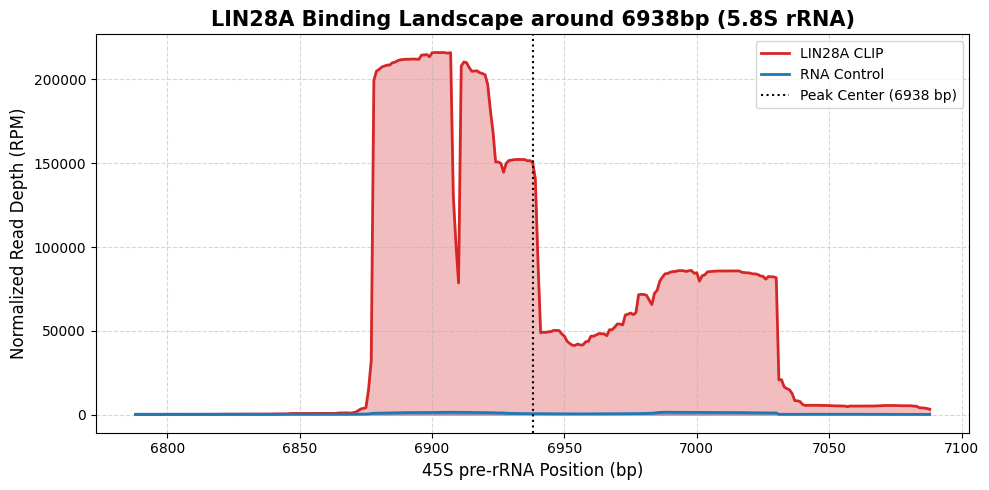

In [27]:
import matplotlib.pyplot as plt

# 1. 5.8S rRNA 핫스팟 (6,938 bp) 주변 150bp (총 300bp 구간) 확대
peak_center = 6938
window = 150
zoom_df = norm_df[(norm_df['Position'] >= peak_center - window) & (norm_df['Position'] <= peak_center + window)]

# 2. 그래프 그리기
plt.figure(figsize=(10, 5))

# CLIP vs Control RPM 비교 플롯
plt.plot(zoom_df['Position'], zoom_df['CLIP_RPM'], label='LIN28A CLIP', color='#D62728', linewidth=2)
plt.plot(zoom_df['Position'], zoom_df['Control_RPM'], label='RNA Control', color='#1F77B4', linewidth=2)

# 곡선 아래 면적 색칠하기
plt.fill_between(zoom_df['Position'], zoom_df['CLIP_RPM'], alpha=0.3, color='#D62728')
plt.fill_between(zoom_df['Position'], zoom_df['Control_RPM'], alpha=0.3, color='#1F77B4')

# 핫스팟 중앙선 표시
plt.axvline(peak_center, color='black', linestyle=':', linewidth=1.5, label=f'Peak Center ({peak_center} bp)')

# 그래프 꾸미기
plt.title(f"LIN28A Binding Landscape around {peak_center}bp (5.8S rRNA)", fontsize=15, fontweight='bold')
plt.xlabel("45S pre-rRNA Position (bp)", fontsize=12)
plt.ylabel("Normalized Read Depth (RPM)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
# 이미 상단에서 세팅된 환경을 사용하여 RNA 2차 구조 예측 툴 설치
import os
import subprocess

env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

print("📦 ViennaRNA 및 시각화 도구 설치 중...")
subprocess.run("conda install -y -c bioconda viennarna", shell=True, env=env)
subprocess.run("conda install -y -c conda-forge ghostscript biopython", shell=True, env=env)
print("✅ 설치 완료!")

📦 ViennaRNA 및 시각화 도구 설치 중...
✅ 설치 완료!


📍 Peak 6938bp 주변의 5.8S rRNA 서열 (61bp):
5'- CGUCGAUGAAGAACGCAGCUAGCUGCGAGAAUUAAUGUGAAUUGCAGGACACAUUGAUCAU -3'

결과 (Dot-Bracket): .............(((((....)))))...(((((((((..........)))))))))...
Minimum Free Energy (MFE): (-13.20)

==== 🧬 LIN28A Binding Site RNA 2차 구조 ====


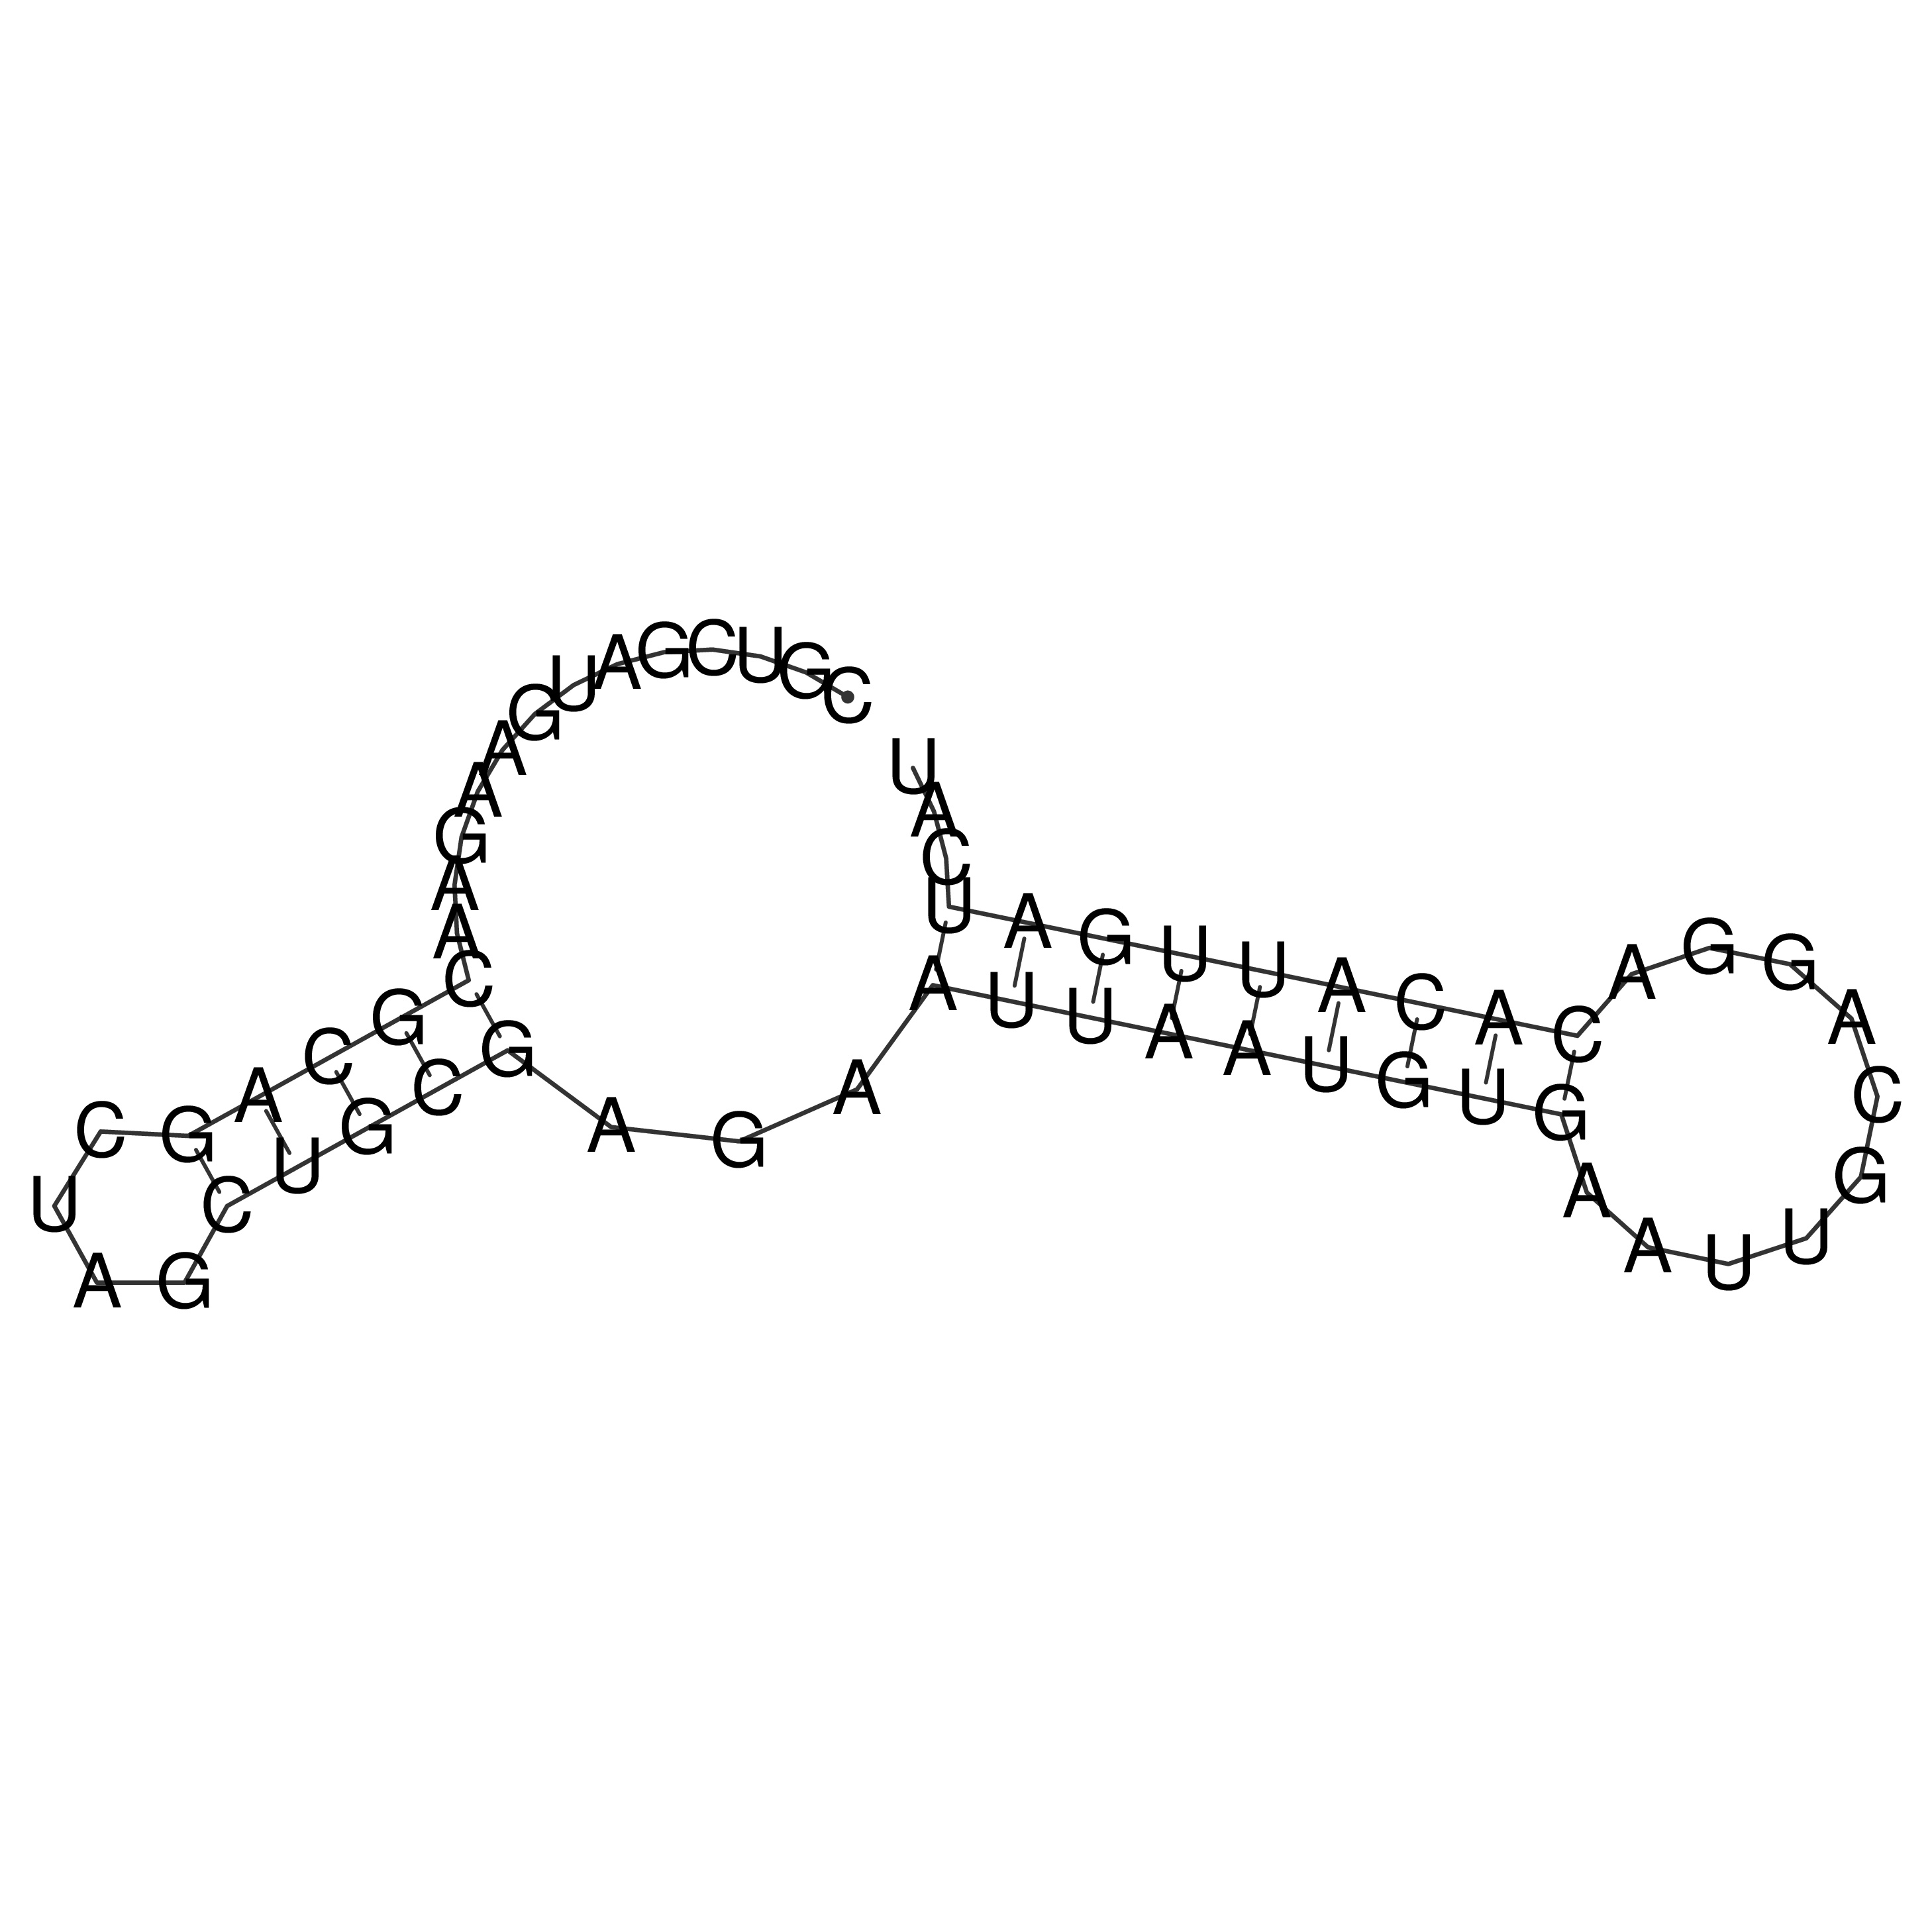

In [31]:
import os
import subprocess
from IPython.display import display, Image

WORKDIR = "/content/binfo1-mywork/rrna_analysis"
rrna_fasta_path = f"{WORKDIR}/mouse_rRNA_ref.fasta"

# 1. FASTA 서열 로드
with open(rrna_fasta_path, "r") as f:
    rrna_seq = "".join([line.strip() for line in f if not line.startswith(">")]).upper()

# 2. 6,938 bp 정확한 서열 추출 (0-based 인덱싱 보정)
target_pos = 6938  # 1-based 생물학적 좌표
target_idx = target_pos - 1 # 0-based 파이썬 인덱스
window = 30 # 주변 구조를 보기 위해 앞뒤로 30bp씩 (총 61bp) 추출

subseq_dna = rrna_seq[target_idx - window : target_idx + window + 1]
subseq_rna = subseq_dna.replace("T", "U") # RNA 구조 예측을 위해 U로 변환

print(f"📍 Peak {target_pos}bp 주변의 5.8S rRNA 서열 (61bp):\n5'- {subseq_rna} -3'\n")

# 3. ViennaRNA 구조 예측 및 Ghostscript 시각화
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

def analyze_rna_structure(sequence, title="RNA Structure"):
    process = subprocess.run(['RNAfold'], input=sequence, text=True, capture_output=True, env=env)
    output = process.stdout.strip().split('\n')

    if len(output) >= 2:
        predicted_structure = output[1].split(' ')[0]
        mfe = output[1][len(predicted_structure):].strip()
        print(f"결과 (Dot-Bracket): {predicted_structure}")
        print(f"Minimum Free Energy (MFE): {mfe}\n")

        ps_file, png_file = "rna.ps", "rna_structure.png"
        if os.path.exists(ps_file):
            # -dEPSCrop 옵션을 추가하여 불필요한 여백을 자르고 이미지 크기를 최적화합니다.
            gs_cmd = [
                "gs", "-dSAFER", "-dBATCH", "-dNOPAUSE",
                "-sDEVICE=png16m",
                "-dGraphicsAlphaBits=4", "-dTextAlphaBits=4",
                "-r300",
                "-dEPSCrop",  # 이미지의 실제 크기에 맞게 자동으로 영역을 맞춤
                f"-sOutputFile={png_file}", ps_file
            ]
            subprocess.run(gs_cmd, capture_output=True)
            if os.path.exists(png_file):
                print("==== 🧬 LIN28A Binding Site RNA 2차 구조 ====")
                display(Image(filename=png_file, width=500))
        else:
            print("❌ 구조 이미지 파일 생성 실패")

analyze_rna_structure(subseq_rna, title=f"LIN28A Binding Site at 5.8S rRNA ({target_pos}bp)")

**[peak 2] CLIP Depth : 13,984인 5' ETS rRNA 2,392bp**

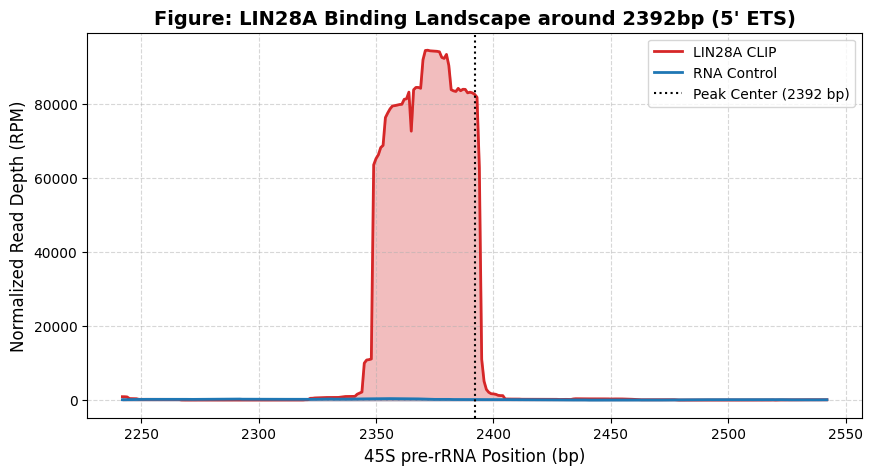

In [32]:
import matplotlib.pyplot as plt

# 2,392 bp 주변 150bp 확대 (총 300bp 구간)
peak_center = 2392
window = 150
zoom_df = norm_df[(norm_df['Position'] >= peak_center - window) & (norm_df['Position'] <= peak_center + window)]

plt.figure(figsize=(10, 5))
plt.plot(zoom_df['Position'], zoom_df['CLIP_RPM'], label='LIN28A CLIP', color='#D62728', linewidth=2)
plt.plot(zoom_df['Position'], zoom_df['Control_RPM'], label='RNA Control', color='#1F77B4', linewidth=2)
plt.fill_between(zoom_df['Position'], zoom_df['CLIP_RPM'], alpha=0.3, color='#D62728')
plt.fill_between(zoom_df['Position'], zoom_df['Control_RPM'], alpha=0.3, color='#1F77B4')
plt.axvline(peak_center, color='black', linestyle=':', linewidth=1.5, label=f'Peak Center ({peak_center} bp)')

plt.title(f"Figure: LIN28A Binding Landscape around {peak_center}bp (5' ETS)", fontsize=14, fontweight='bold')
plt.xlabel("45S pre-rRNA Position (bp)", fontsize=12)
plt.ylabel("Normalized Read Depth (RPM)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

📍 Peak 2392bp 주변의 5' ETS 서열 (61bp):
5'- UCAGGGGAGUGGUGCAGUGUGAUUCCCGCCGGUUUUGCCUCGCGUGCCCUGACCGGUCCGA -3'

결과 (Dot-Bracket): ....((((((...........))))))(((((((..(((....).))...)))))))....
Minimum Free Energy (MFE): (-18.30)

==== 🧬 LIN28A Binding Site RNA 2차 구조 ====


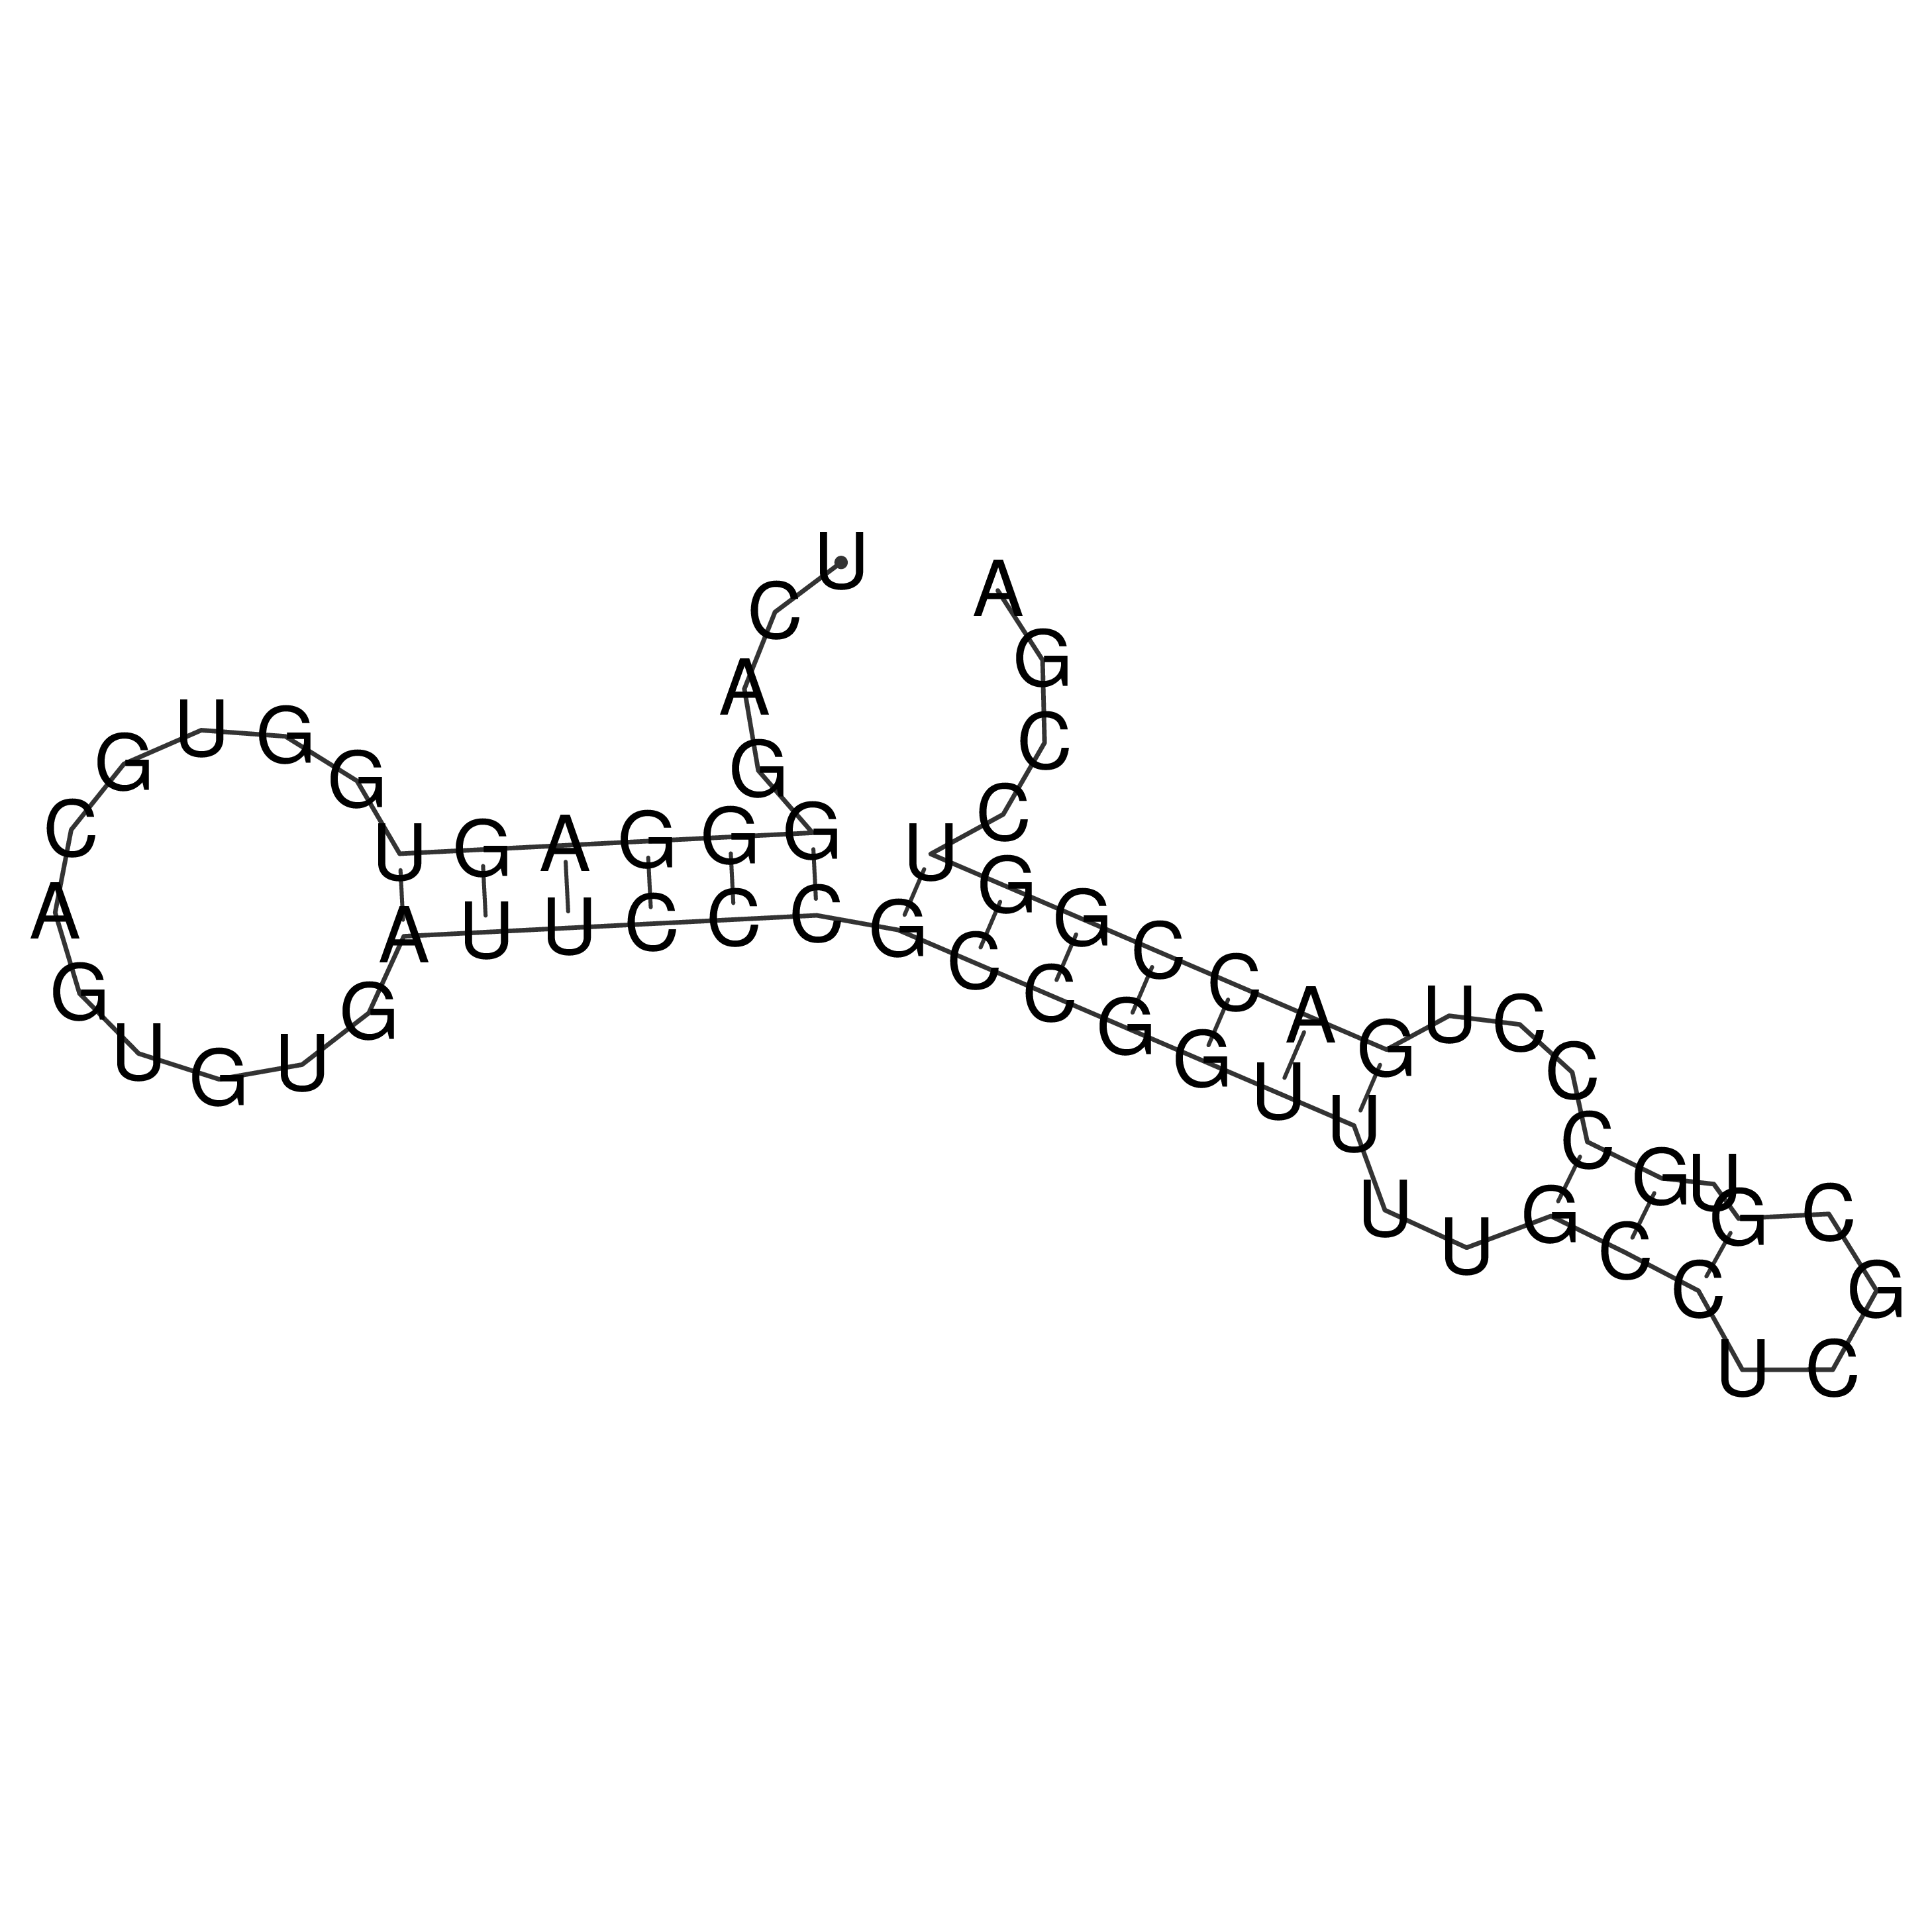

In [33]:
# 2,392 bp 정확한 서열 추출
target_pos = 2392
target_idx = target_pos - 1
window = 30 # 주변 61bp 추출

subseq_dna = rrna_seq[target_idx - window : target_idx + window + 1]
subseq_rna = subseq_dna.replace("T", "U")

print(f"📍 Peak {target_pos}bp 주변의 5' ETS 서열 (61bp):\n5'- {subseq_rna} -3'\n")

# 구조 분석 실행
analyze_rna_structure(subseq_rna, title=f"LIN28A Binding Site at 5' ETS ({target_pos}bp)")

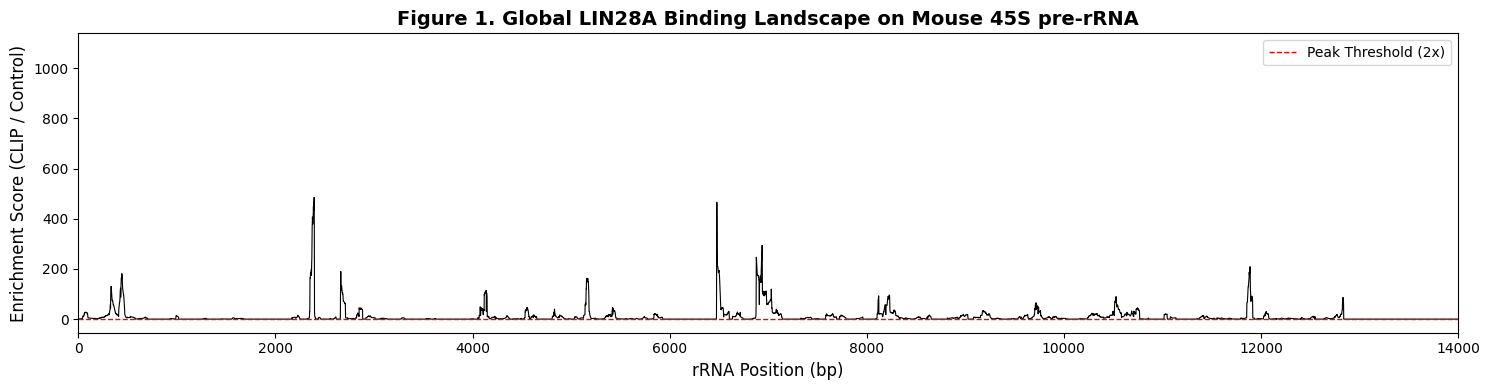

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
# 전체 영역에 대해 Enrichment Score 플롯
plt.plot(norm_df['Position'], norm_df['Enrichment_Score'], color='black', linewidth=0.8)

plt.axhline(y=2, color='red', linestyle='--', linewidth=1, label='Peak Threshold (2x)')
plt.title("Figure 1. Global LIN28A Binding Landscape on Mouse 45S pre-rRNA", fontsize=14, fontweight='bold')
plt.xlabel("rRNA Position (bp)", fontsize=12)
plt.ylabel("Enrichment Score (CLIP / Control)", fontsize=12)
plt.xlim(0, 14000) # 주요 전사체 구간(45S)만 확대해서 보기
plt.legend()
plt.tight_layout()
plt.show()